### 1. Data Preparation:

In [1]:
### Import all necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.preprocessing import LabelEncoder 

In [2]:
### Load the Dataset
df=pd.read_excel('heart_disease.xlsx',sheet_name=1)

In [3]:
### Data size
df.shape

(908, 13)

In [4]:
### Data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [5]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


### 2. EDA:

In [6]:
### Duplicates
df.duplicated().sum()

np.int64(1)

In [7]:
### Drop duplicate
df.drop_duplicates(inplace=True,ignore_index=True)

In [8]:
###  After droping Duplicates
df.duplicated().sum()

np.int64(0)

In [9]:
### Missing values
df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

In [10]:
df["oldpeak"] = df["oldpeak"].fillna(df["oldpeak"].median())

* The oldpeak column had 62 missing values.
* These missing values were filled using the median.
* This ensured that all missing values were handled without significantly affecting the data distribution.

In [11]:
###  After filling Missing values
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64

In [12]:
df["cp"].unique()

array(['typical angina', 'atypical angina', 'asymptomatic', 'non-anginal'],
      dtype=object)

In [13]:
df["exang"].unique()

array([False, True, 'FALSE', 'TURE'], dtype=object)

In [14]:
df["exang"] = df["exang"].replace({
    "FALSE": False,
    "TURE": True
})

    The exang column contained inconsistent Boolean and string values. The incorrect string values ("FALSE" and "TURE") were replaced with their corresponding Boolean values (False and True) to maintain consistency and prepare the data for further preprocessing.

In [15]:
# Boolean columns to integer
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

# Label encode categorical columns
cat_cols = df.select_dtypes(include='object').columns

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [16]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,1,3,145,233,1,0,150,0,2.3,0,0,0
1,41,1,1,135,203,0,1,132,0,0.0,1,0,0
2,57,1,0,140,192,0,1,148,0,0.4,1,0,0
3,52,1,3,118,186,0,0,190,0,0.0,1,0,0
4,57,1,0,110,201,0,1,126,1,1.5,1,0,0


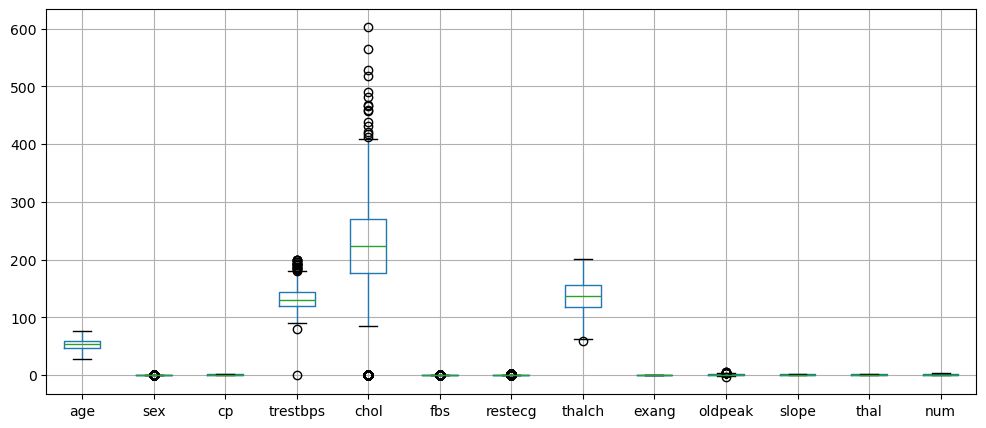

In [17]:
### Outlier checking
plt.figure(figsize=(12,5))
df.boxplot()
plt.show()

In [18]:
##### Outlier capping
def outlier_capping(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_extreme = Q1 - 1.5 * IQR
    upper_extreme = Q3 + 1.5 * IQR
    df[column] = df[column].apply(lambda x: lower_extreme if x < lower_extreme else upper_extreme if x > upper_extreme else x)

continuous_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
for col in continuous_cols:
    outlier_capping(df, col)

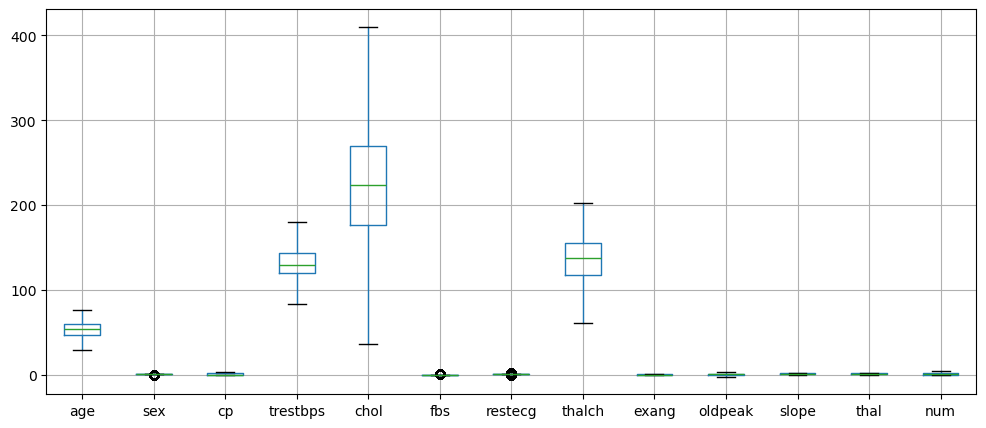

In [19]:
### after Outlier capping
plt.figure(figsize=(12,5))
df.boxplot()
plt.show() 

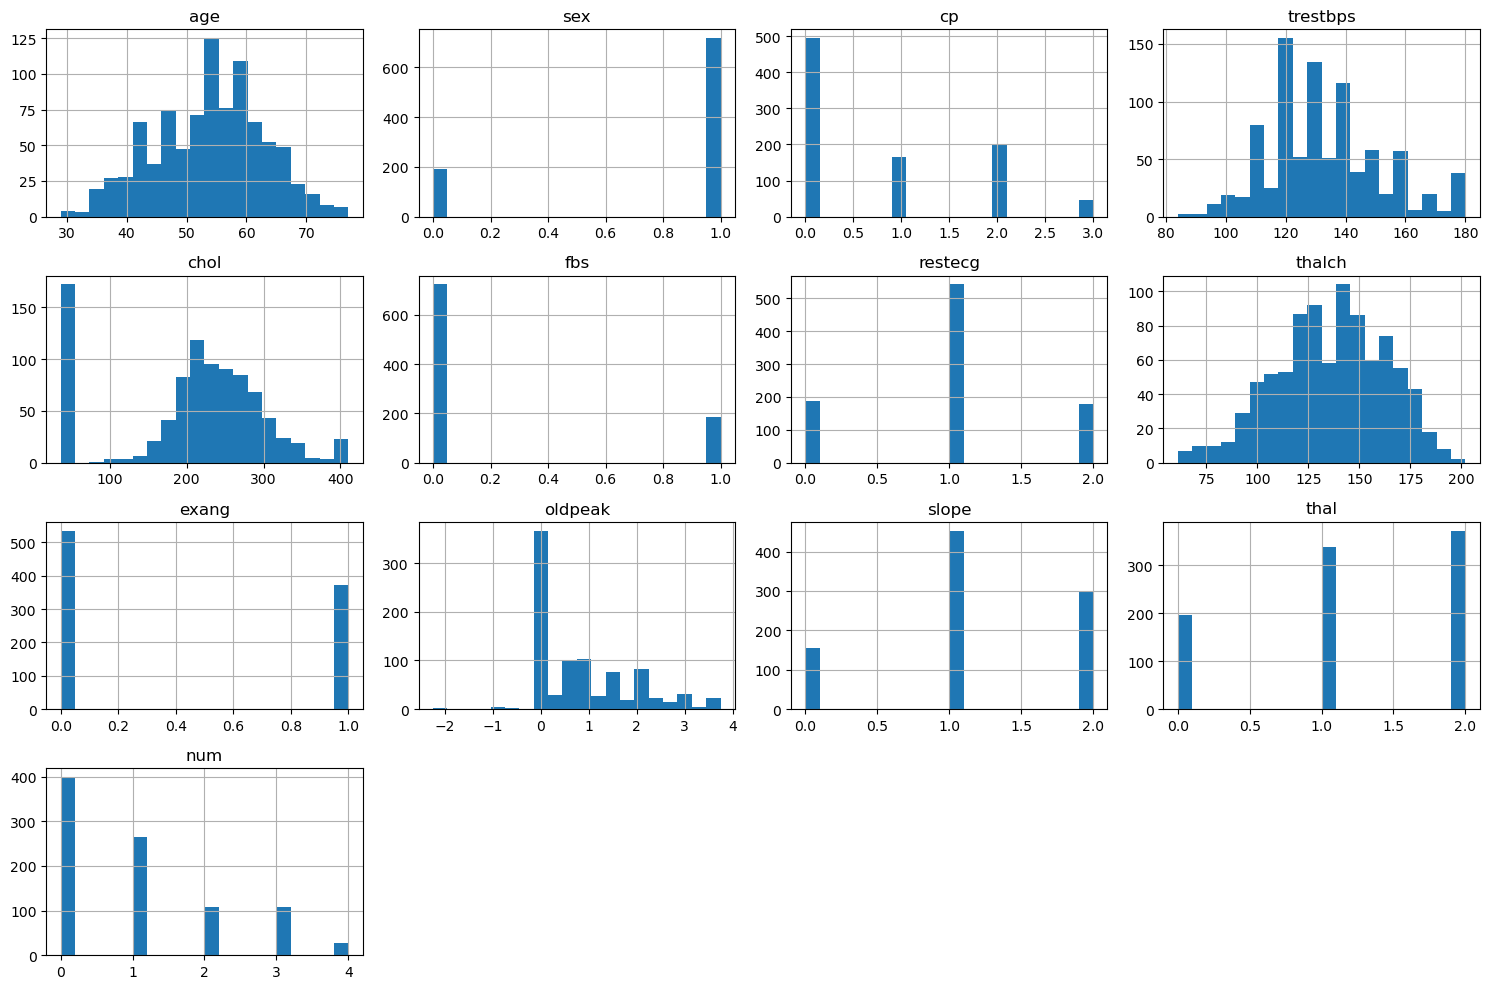

In [20]:
### Histogram for feature distribution
df.hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()

* Most numerical features show a reasonable distribution, while chol and oldpeak are slightly right-skewed.
* Age, trestbps, and thalch are concentrated around their middle values.
* Categorical features (sex, cp, fbs, restecg, exang, slope, thal) show the frequency of each category.
* The target variable (num) is not evenly distributed, with class 0 having the highest number of observations.

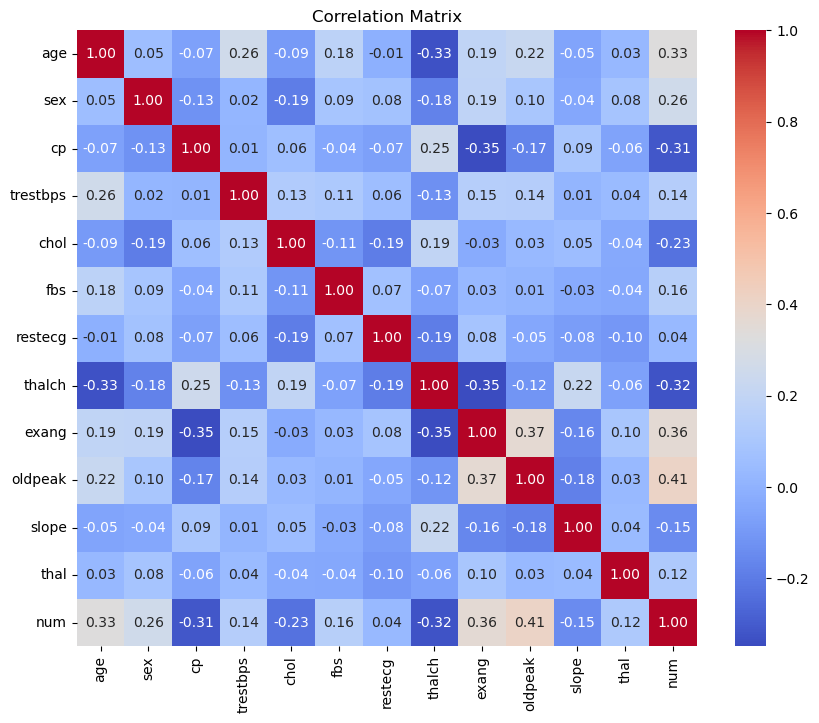

In [21]:
### Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

The heatmap shows that most of the columns do not have a strong link to each other. **oldpeak** (stress test score) and **exang** (chest pain during exercise) have the strongest connection to the target variable **num** (heart disease), while the rest of the columns show weak connections.


### 3. Feature Engineering:

    We prepared our data for the machine learning model by doing three simple things:

1. **Fixed Typos:** We cleaned up the mixed-up text patterns and spelling errors in the `exang` column.
2. **Filled Gaps:** We found missing values in the `oldpeak` column and filled them with the middle value (median) so no data was wasted.
3. **Turned Text into Numbers:** Since computers only understand numbers, we safely converted columns like `sex`, `cp`, and `thal` into numerical codes. 
4. **Capped Outliers:** We limited extreme values in continuous columns like `chol` and `trestbps` so they wouldn't throw off our model's logic.


### 4. Decision Tree Classification:

In [22]:
target = df['num']
features = df.drop(columns=['num'])

In [23]:
x_train, x_test, y_train, y_test = train_test_split(features, target, train_size=0.8, random_state=200, stratify=target)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(725, 12)
(182, 12)
(725,)
(182,)


In [24]:
### Model Building
dec_tree = DecisionTreeClassifier(criterion='entropy',splitter='best',max_depth=4,random_state=200)
dec_tree.fit(x_train,y_train)
y_pred= dec_tree.predict(x_test)
accuracy_score(y_test,y_pred)

0.521978021978022

In [25]:
###Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.79      0.72        80
           1       0.42      0.51      0.46        53
           2       0.25      0.09      0.13        22
           3       0.19      0.14      0.16        21
           4       0.00      0.00      0.00         6

    accuracy                           0.52       182
   macro avg       0.31      0.31      0.30       182
weighted avg       0.47      0.52      0.49       182



### 5. Hyperparameter Tuning

In [26]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'splitter': ['best', 'random']
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=200),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...dom_state=200)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.

In [27]:
print("Best Parameters:", grid_search.best_params_)
print("Best Cross Validation Score:", grid_search.best_score_)

Best Parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'splitter': 'random'}
Best Cross Validation Score: 0.5710344827586207


In [28]:
### Best Model
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(x_test)
accuracy_score(y_test, y_pred_best)

0.521978021978022

    Hyperparameter tuning was performed using GridSearchCV to find the optimal Decision Tree parameters. The tuned model achieved an accuracy of 52.20% on the test dataset. The performance is similar to the initial model, indicating that parameter tuning did not significantly improve the model. This may be due to the multiclass nature of the dataset and the complexity of the classification problem.

### 6. Model Evaluation and Analysis:

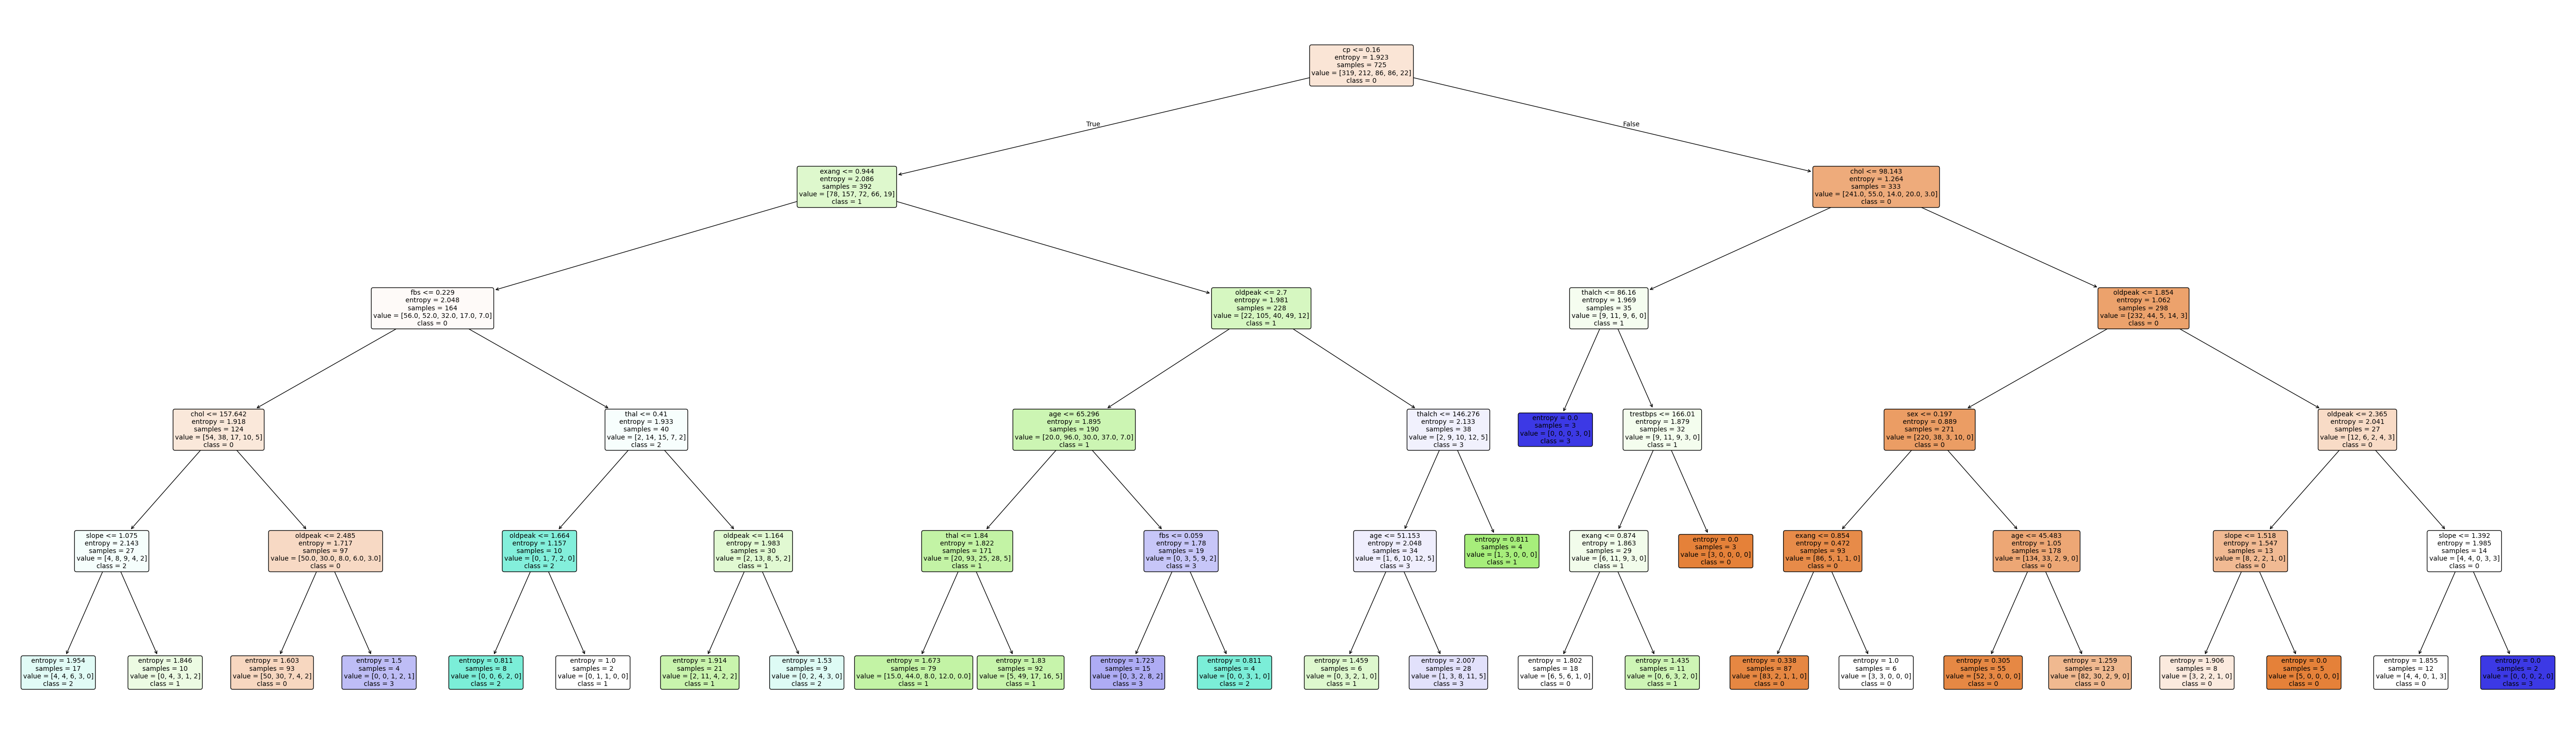

In [35]:
plt.figure(figsize=(70,20))

plot_tree(
    best_model,
    feature_names=features.columns,
    class_names=[str(i) for i in best_model.classes_],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.show()

In [36]:
feature_importance = pd.DataFrame({
    "Feature": features.columns,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
2,cp,0.358059
9,oldpeak,0.134149
4,chol,0.112931
8,exang,0.101865
0,age,0.079547
5,fbs,0.058638
11,thal,0.039904
7,thalch,0.039060
10,slope,0.038144
1,sex,0.023649


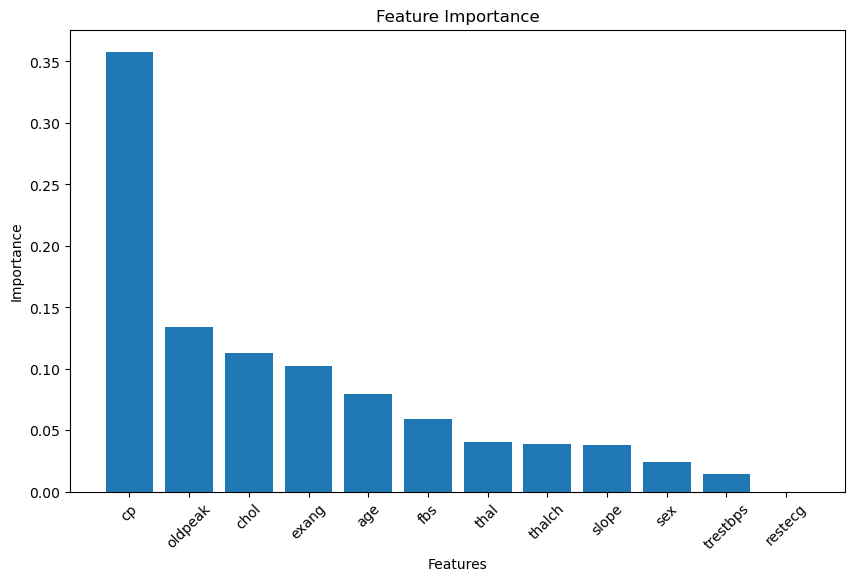

In [37]:
plt.figure(figsize=(10,6))
plt.bar(feature_importance["Feature"], feature_importance["Importance"])
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.show()

#### Key Findings
* Most important feature: Chest Pain Type (cp) – 0.358
* Other important features: oldpeak, chol, exang, and age
* Least important feature: restecg – 0.000

#### Conclusion

A Decision Tree Classification model was developed to predict heart disease using patient health data. The dataset was preprocessed by handling missing values, treating outliers, and encoding categorical variables. The model was trained and evaluated using accuracy, precision, recall, and F1-score. Hyperparameter tuning was performed using GridSearchCV to optimize the model. The tuned model achieved an accuracy of approximately 52%. The decision tree visualization and feature importance analysis showed that Chest Pain Type (cp), oldpeak, cholesterol (chol), and exercise-induced angina (exang) were the most influential features in predicting heart disease.

### Interview Questions:

#### 1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?

* criterion: Determines how the tree measures the quality of a split (gini or entropy).
* max_depth: Limits the maximum depth of the tree. Smaller values reduce overfitting, while larger values increase model complexity.
* min_samples_split: Specifies the minimum number of samples required to split a node. Higher values help reduce overfitting.
* min_samples_leaf: Specifies the minimum number of samples required at a leaf node. It creates smoother and more generalized trees.
* splitter: Determines how the split is selected. best chooses the optimal split, while random selects a random split.

#### 2. What is the difference between Label Encoding and One-Hot Encoding?

#### Label Encoding
* Label Encoding converts each category into a unique numerical value.
* It stores the encoded values in a single column.
* It is suitable for ordinal data, where categories have a natural order.
* It is memory efficient because it does not increase the number of features.
* Example: Low = 0, Medium = 1, High = 2.
#### One-Hot Encoding
* One-Hot Encoding creates a separate binary column for each category.
* Each category is represented by either 0 or 1.
* It is suitable for nominal data, where categories do not have any natural order.
* It increases the number of columns in the dataset but avoids introducing a false order among categories.
* Example:
    Red = (1, 0, 0)
    Blue = (0, 1, 0)
    Green = (0, 0, 1)